In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
from pathlib import Path

# Path setup (relative to this notebook file) 
notebook_path = Path("plotting.ipynb").resolve()
script_dir = notebook_path.parent 
csv_folder = script_dir / "Auto_Logged_data_April7_MPC"

print("Notebook dir:", script_dir)
print("CSV folder:", csv_folder)

Notebook dir: C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April7_2026
CSV folder: C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April7_2026\Auto_Logged_data_April7_MPC


In [39]:
# choose files to plot (all CSVs in the folder)
selected_files = sorted([p.name for p in csv_folder.glob("*.csv")])
print("Selected files:")
for f in selected_files:
    print(f)


Selected files:
Data_Apr7_MPC_10kph_FV2.csv
Data_Apr7_MPC_10kph_FV3.csv
Data_Apr7_MPC_5kph_FV1.csv


In [40]:
data = {}
for file in selected_files:
    path = os.path.join(csv_folder, file)
    df = pd.read_csv(path)

    # Check if DataFrame is empty or missing required columns
    if df.empty:
        print(f"Skipping {file}: empty DataFrame")
        continue
    if "Time(s)" not in df.columns:
        print(f"Skipping {file}: missing 'Time(s)' column")
        continue

    
    # normalize time for this file
    df["Time"] = df["Time(s)"] - df["Time(s)"].iloc[0]
    # convert to km/h (and keep the original m/s if you want)
    df["Ego_Velocity_kmph"] = df["Ego_Velocity(m/s)"] * 3.6
    if "Obs_Velocity(m/s)" in df.columns:
        df["Obs_Velocity_kmph"] = df["Obs_Velocity(m/s)"] * 3.6

    data[file] = df

    print(file, "loaded")
    display(df.head())

Data_Apr7_MPC_10kph_FV2.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Throttle_command,Time,Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,NaN,NaN,NaN,0.000010,0.344265,0.000000,0.0,NaN
1,0.0,0.0,NaN,NaN,NaN,NaN,0.080550,0.688528,0.080540,0.0,NaN
2,0.0,0.0,NaN,NaN,NaN,NaN,0.185603,1.029903,0.185593,0.0,NaN
3,0.0,0.0,NaN,NaN,NaN,NaN,0.312195,1.343828,0.312185,0.0,NaN
4,0.0,0.0,NaN,NaN,NaN,NaN,0.400028,1.633979,0.400018,0.0,NaN


Data_Apr7_MPC_10kph_FV3.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Throttle_command,Time,Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,NaN,NaN,NaN,0.000010,0.34426486292632474,0.000000,0.0,NaN
1,0.0,0.0,NaN,NaN,NaN,NaN,7.346518,0.6885280318633731,7.346509,0.0,NaN
2,0.0,0.0,NaN,NaN,NaN,NaN,7.456471,1.0299033823483585,7.456461,0.0,NaN
3,0.0,0.0,NaN,NaN,NaN,NaN,7.590312,1.343827759824719,7.590302,0.0,NaN
4,0.0,0.0,NaN,NaN,NaN,NaN,7.673225,1.633979037118703,7.673215,0.0,NaN


Data_Apr7_MPC_5kph_FV1.csv loaded


,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Separation(m),Relative velocity(m/s),Time(s),Throttle_command,Time,Ego_Velocity_kmph,Obs_Velocity_kmph
0,0.0,0.0,NaN,NaN,NaN,NaN,0.000006,0.344268,0.000000,0.0,NaN
1,0.0,0.0,13.5,0.0,NaN,0.0,6.392655,0.688533,6.392649,0.0,0.0
2,0.0,0.0,13.5,0.0,NaN,0.0,6.512004,1.029908,6.511998,0.0,0.0
3,0.0,0.0,NaN,NaN,NaN,NaN,6.593210,1.110825,6.593204,0.0,NaN
4,0.0,0.0,NaN,NaN,NaN,NaN,6.720264,1.110824,6.720258,0.0,NaN


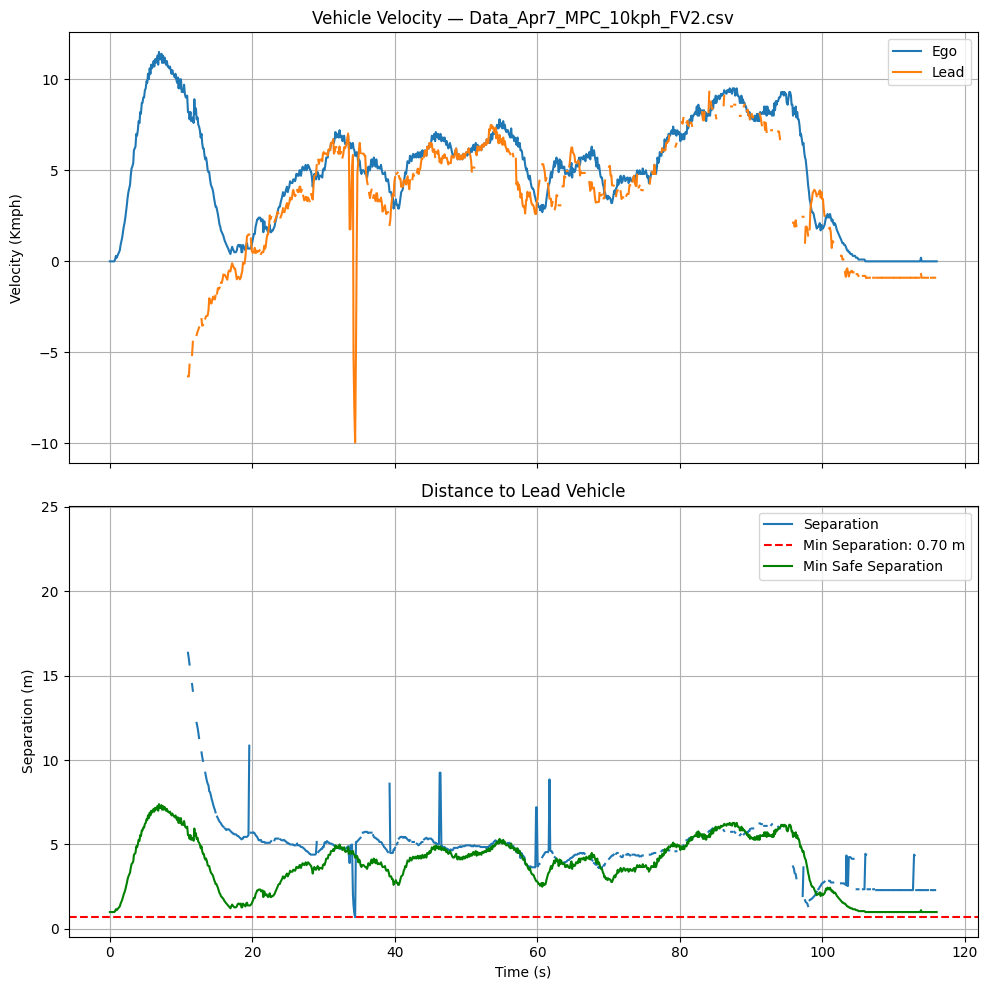

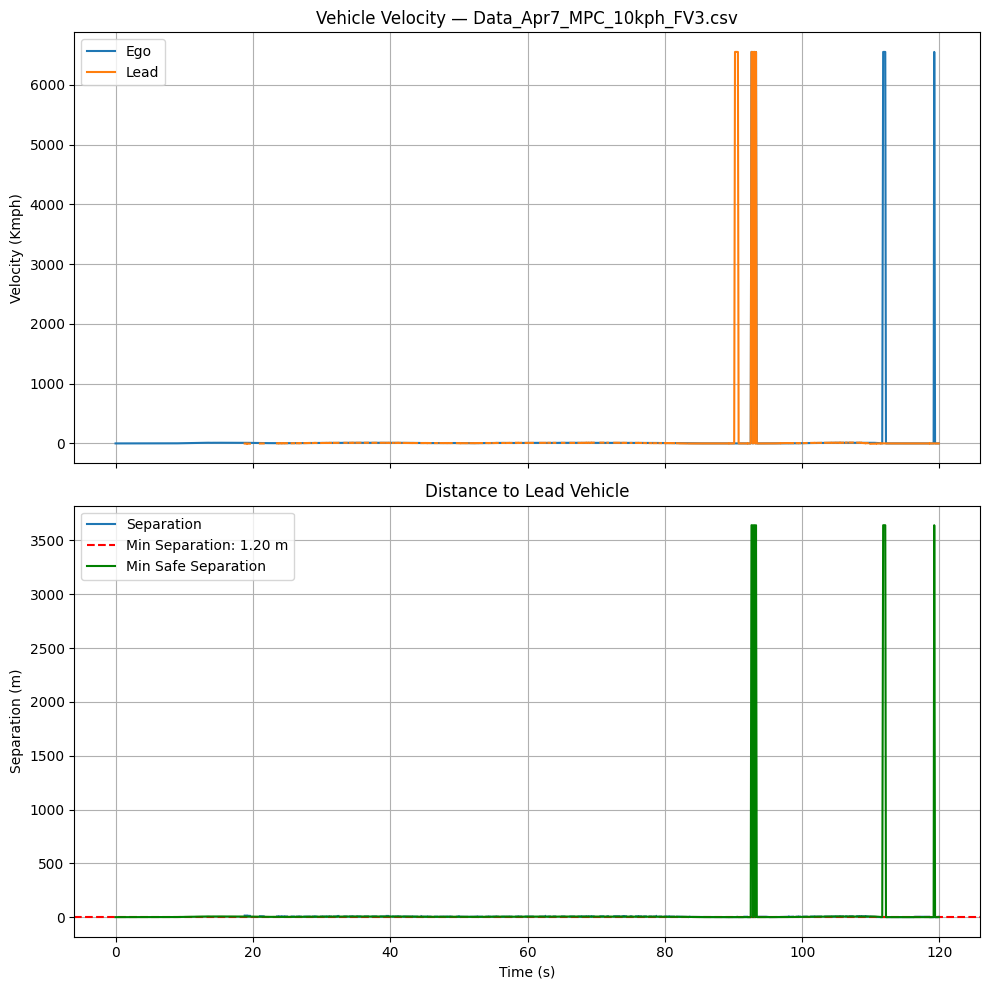

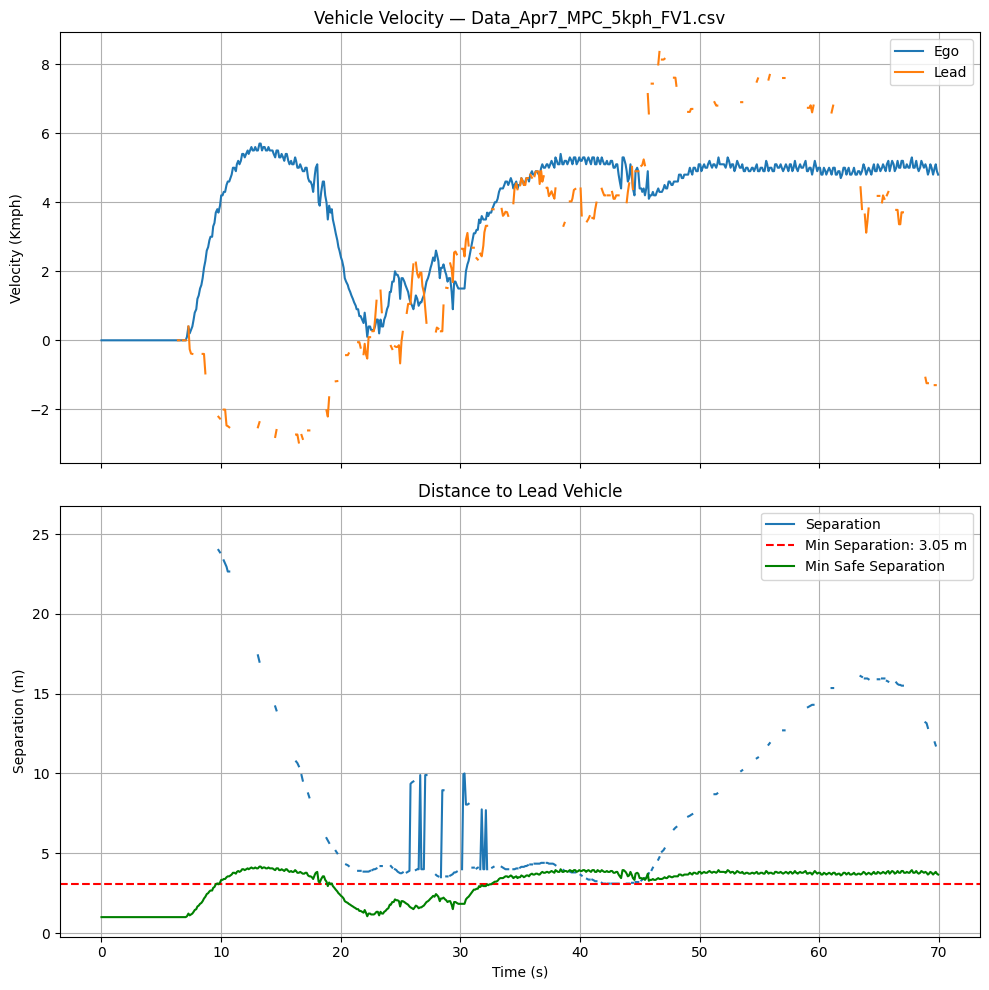

In [41]:
for file, df in data.items():
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # ---- Velocity ----
    axes[0].plot(df["Time"], df["Ego_Velocity_kmph"], label="Ego")
    if "Obs_Velocity_kmph" in df.columns:
        axes[0].plot(df["Time"], df["Obs_Velocity_kmph"], linestyle="-", label="Lead")

    # ---- Separation ----
    if "Separation(m)" in df.columns:
        axes[1].plot(df["Time"], df["Separation(m)"], label="Separation")
        # Min of sep 
        minimum_separation = df["Separation(m)"].min()
        axes[1].axhline(minimum_separation, color='red', linestyle='--', label=f'Min Separation: {minimum_separation:.2f} m')

    # Minimum safe separation line ( 2 seconds at current speed + min safe distance)
    if "Ego_Velocity_kmph" in df.columns:
        min_sep = df["Ego_Velocity_kmph"] * (1000/3600) * 2 + 1  # 2 seconds gap in meters + min safe distance
        axes[1].plot(df["Time"], min_sep, linestyle="-", color="green", label="Min Safe Separation")


    axes[0].set_ylabel("Velocity (Kmph)")
    axes[0].set_title(f"Vehicle Velocity — {file}")

    axes[1].set_ylabel("Separation (m)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Distance to Lead Vehicle")

    for ax in axes:
        ax.grid()
        ax.legend()

    plt.tight_layout()
    plt.show()

In [42]:
def clean_velocity_series(v,
                          min_val=0.0,
                          max_val=20.0,         # adjust for your vehicle
                          max_jump=1.0,         # km/h per sample
                          interp_limit=5,
                          rolling_window=5):
    v = pd.to_numeric(v, errors="coerce")
    v.loc[v > 100] = 0.0           # drop garbage high spikes on stop
    v = v.clip(lower=min_val, upper=max_val)
    dv = v.diff().abs()
    v.loc[dv > max_jump] = np.nan # remove spikes
    v = v.interpolate(method="quadratic", limit=interp_limit, limit_direction="both") # fill short gaps
    v = v.rolling(window=rolling_window, center=True, min_periods=1).median() # smooth
    return v


In [43]:
def clean_separation_series_timeaware(sep, t, rel_vel_kmph=None,
                                      min_sep=1.0, max_sep=40.0,
                                      base_rate_limit=0.5,   # m/s
                                      rel_vel_gain=0.5,      # extra limit from |relative speed|
                                      median_window=5,
                                      ema_alpha=0.25):
    s = pd.to_numeric(sep, errors="coerce").clip(lower=min_sep, upper=max_sep)
    t = pd.to_numeric(t, errors="coerce")
    dt = t.diff().replace(0, np.nan)

    # Rate-of-change limit in m/s (dynamic from relative speed if available)
    if rel_vel_kmph is not None:
        rv = pd.to_numeric(rel_vel_kmph, errors="coerce").abs() / 3.6
        limit = base_rate_limit + rel_vel_gain * rv
    else:
        limit = base_rate_limit

    dsdt = s.diff().abs() / dt
    s.loc[dsdt > limit] = np.nan

    # Fill short gaps, then robust smooth
    s = s.interpolate(limit=6, limit_direction="both")
    s = s.rolling(median_window, center=True, min_periods=1).median()
    s = s.ewm(alpha=ema_alpha, adjust=False).mean()

    return s

## For Following vehicle Scenario

In [44]:
for file, df in data.items():
    # Clean raw velocity
    df["Ego_Velocity_clean"] = clean_velocity_series(df["Ego_Velocity_kmph"],
                                                     min_val=0.0, max_val=20.0, max_jump=0.2)
    if "Obs_Velocity_kmph" in df.columns:
        df["Obs_Velocity_clean"] = clean_velocity_series(df["Obs_Velocity_kmph"],
                                                         min_val=-0.1, max_val=20.0, max_jump=0.14)
    else:
        df["Obs_Velocity_clean"] = np.nan


    if "Separation(m)" in df.columns:
        rel_vel = None
        if "Obs_Velocity_clean" in df.columns and "Ego_Velocity_clean" in df.columns:
            rel_vel = df["Obs_Velocity_clean"] - df["Ego_Velocity_clean"]

        df["Separation_clean"] = clean_separation_series_timeaware(
            df["Separation(m)"],
            df["Time"],
            rel_vel_kmph=rel_vel
        )
    else:
        df["Separation_clean"] = np.nan

    # Recompute Ego position from clean ego velocity
    dt = df["Time"].diff().fillna(0)
    df["Ego_Position_clean"] = (df["Ego_Velocity_clean"].fillna(0) / 3.6) * dt
    df["Ego_Position_clean"] = df["Ego_Position_clean"].cumsum()
    if "Ego_Position(m)" in df.columns:
        df["Ego_Position_clean"] += df["Ego_Position(m)"].iloc[0]

    # Recompute Obs position via separation
    df["Obs_Position_clean"] = df["Ego_Position_clean"] + df["Separation_clean"]

    # Optionally, nothing is dropped: persist all intermediate
    data[file] = df

In [45]:
alpha = 0.2
dt_prev = 0

for file, df in data.items():
    prev_obs_vel = np.nan  
    prev_obs_pos = np.nan
    prev_sep = np.nan
    prev_ego_vel = np.nan

    for i in range(len(df)):
        obs_vel_r = df.loc[i, "Obs_Velocity_clean"]
        obs_pos_r = df.loc[i, "Obs_Position_clean"]
        ego_pos_i = df.loc[i, "Ego_Position_clean"]
        ego_vel_i = df.loc[i, "Ego_Velocity_clean"]
        time_i = df.loc[i, "Time"]

        # ---- Compute time step ----
        if i > 0:
            dt = time_i - df.loc[i-1, "Time"]
        else:
            dt = 0

        # ---- Low-pass filter on RELATIVE velocity (more robust) ----
        if pd.notna(obs_vel_r) and pd.notna(ego_vel_i):
            rel_vel = obs_vel_r - ego_vel_i
            if pd.notna(prev_obs_vel) and pd.notna(prev_ego_vel):
                prev_rel_vel = prev_obs_vel - prev_ego_vel
                rel_vel_f = alpha * prev_rel_vel + (1 - alpha) * rel_vel
            else:
                rel_vel_f = rel_vel
            obs_vel_f = ego_vel_i + rel_vel_f
        else:
            obs_vel_f = obs_vel_r

        # ---- Adaptive position outlier rejection (scales with speed) ----
        speed_factor = max(abs(ego_vel_i) if pd.notna(ego_vel_i) else 0, 
                          abs(obs_vel_r) if pd.notna(obs_vel_r) else 0) / 3.6
        pos_threshold = 2 + 0.5 * speed_factor

        if np.isnan(obs_pos_r):
            obs_pos_f = prev_obs_pos
        else:
            if pd.notna(prev_obs_pos) and abs(obs_pos_r - prev_obs_pos) > pos_threshold:
                obs_pos_f = prev_obs_pos  # reject large jumps
            else:
                obs_pos_f = obs_pos_r

        # ---- Predict position from relative velocity ----
        if pd.notna(prev_obs_pos) and pd.notna(obs_vel_f) and dt > 0:
            predicted_pos = prev_obs_pos + (obs_vel_f / 3.6) * dt
            # If measured position deviates too much from prediction, use prediction
            if pd.notna(obs_pos_f) and abs(obs_pos_f - predicted_pos) > 0.6:
                obs_pos_f = predicted_pos

        # ---- Compute separation ----
        sep = obs_pos_f - ego_pos_i

        # ---- Allow realistic separation changes from relative motion ----
        if pd.notna(prev_sep) and pd.notna(sep) and pd.notna(prev_obs_vel) and pd.notna(prev_ego_vel) and dt > 0:
            expected_sep_change = ((prev_obs_vel - prev_ego_vel) / 3.6) * dt
            max_sep_deviation = 0.6 + 0.3 * abs(expected_sep_change)  # tolerance for noise
            
            if abs(sep - prev_sep - expected_sep_change) > max_sep_deviation:
                # Large deviation from expected = measurement error
                sep = prev_sep + expected_sep_change

        df.at[i, "Obs_Velocity_clean"] = obs_vel_f
        df.at[i, "Obs_Position_clean"] = obs_pos_f
        df.at[i, "Separation_clean"] = sep

        prev_obs_vel = obs_vel_f
        prev_obs_pos = obs_pos_f
        prev_sep = sep
        prev_ego_vel = ego_vel_i

### Saving the cleaned data to new folder for further use. 

In [46]:
output_folder = script_dir / "Processed_Data_April7_MPC"
output_folder.mkdir(exist_ok=True)  
for file, df in data.items():
    output_path = output_folder / file
    df.to_csv(output_path, index=False)
    print(f"Saved cleaned data to {output_path}")

Saved cleaned data to C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April7_2026\Processed_Data_April7_MPC\Data_Apr7_MPC_10kph_FV2.csv
Saved cleaned data to C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April7_2026\Processed_Data_April7_MPC\Data_Apr7_MPC_10kph_FV3.csv
Saved cleaned data to C:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April7_2026\Processed_Data_April7_MPC\Data_Apr7_MPC_5kph_FV1.csv


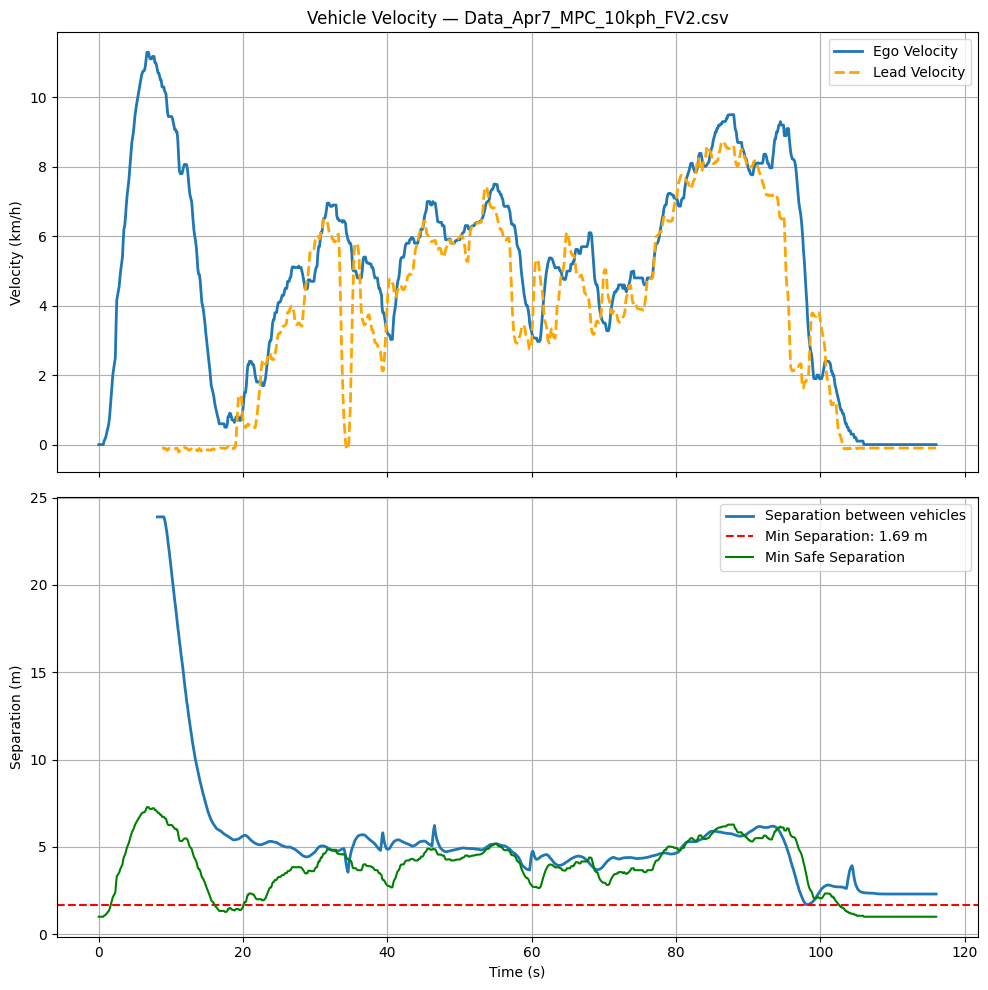

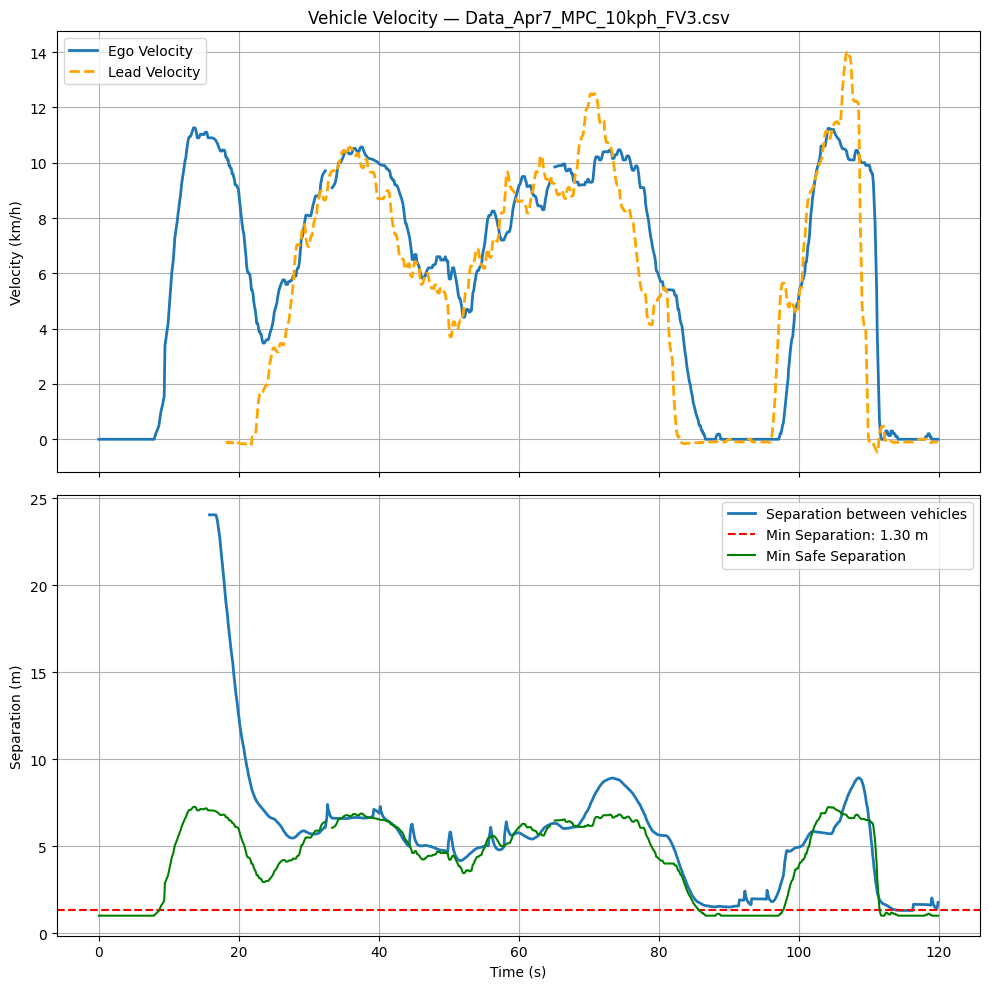

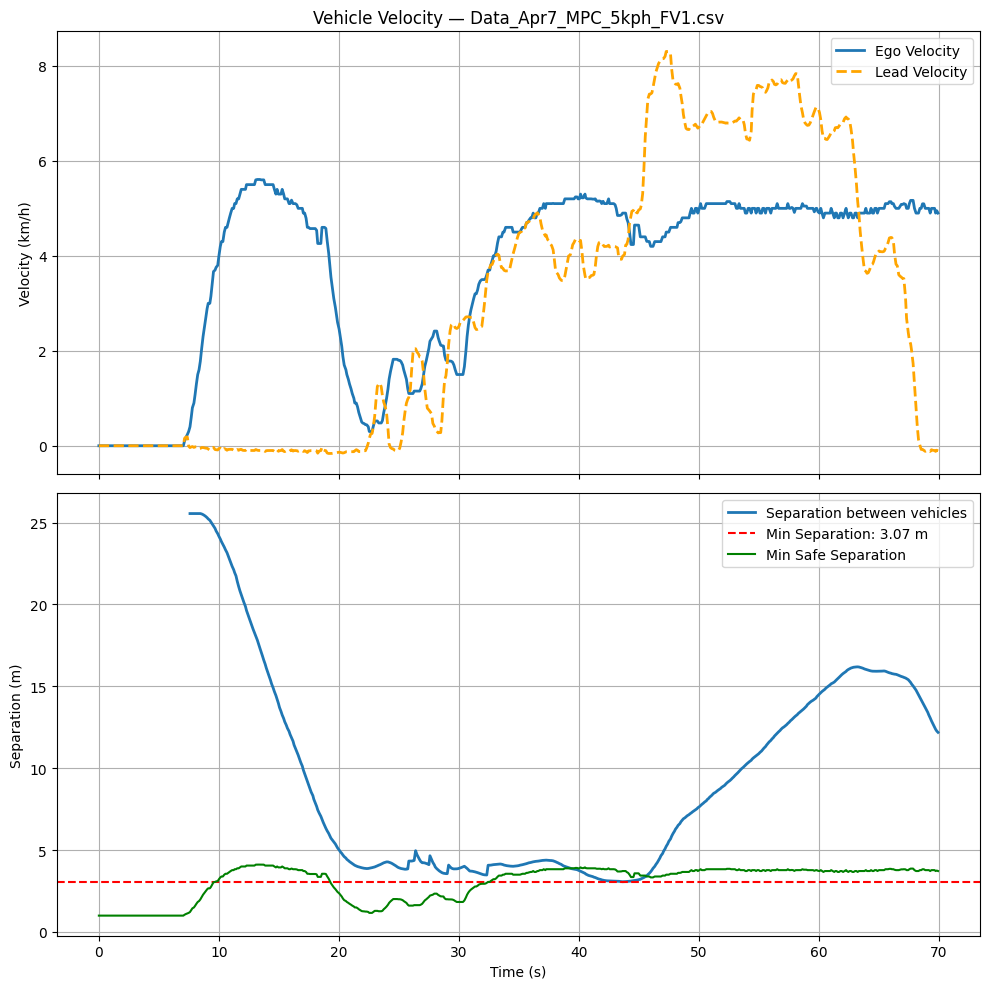

In [47]:
for file, df in data.items():
    fig, axes = plt.subplots(2,1,figsize=(10,10), sharex=True)

    axes[0].plot(df["Time"], df["Ego_Velocity_clean"], label="Ego Velocity", linewidth=2)
    # axes[0].plot(df["Time"], df["Ego_Velocity_kmph"], alpha=0.3, label="Ego raw")
    if "Obs_Velocity_clean" in df.columns:
        axes[0].plot(df["Time"], df["Obs_Velocity_clean"], color="orange",linewidth=2, linestyle='--', label="Lead Velocity")
    axes[0].set_ylabel("Velocity (km/h)")
    axes[0].set_title(f"Vehicle Velocity — {file}")
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(df["Time"], df["Separation_clean"], label="Separation between vehicles", linewidth=2)
    minimum_separation = df["Separation_clean"].min()
    axes[1].axhline(minimum_separation, color='red', linestyle='--', label=f'Min Separation: {minimum_separation:.2f} m')
    axes[1].set_ylabel("Separation (m)")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend()
    axes[1].grid()

    # Minimum separation line ( 2 seconds at current speed + min safe distance)
    if "Ego_Velocity_clean" in df.columns:
        min_sep = df["Ego_Velocity_clean"] * (1000/3600) * 2 + 1  # 2 seconds gap in meters + min safe distance
        axes[1].plot(df["Time"], min_sep, linestyle="-", color="green", label="Min Safe Separation")
        axes[1].legend()

    plt.tight_layout()
    plt.show()

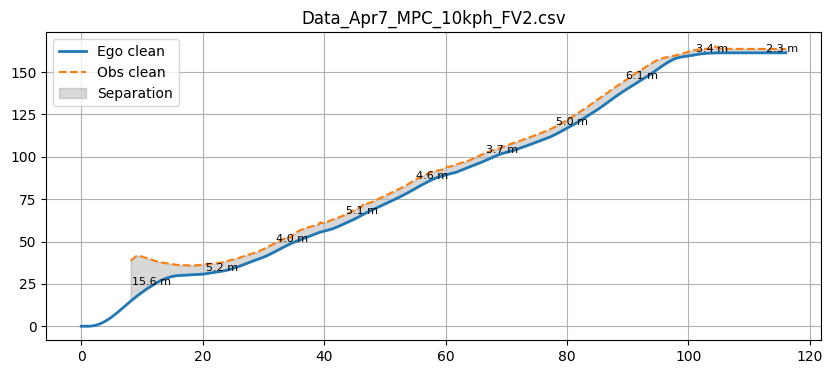

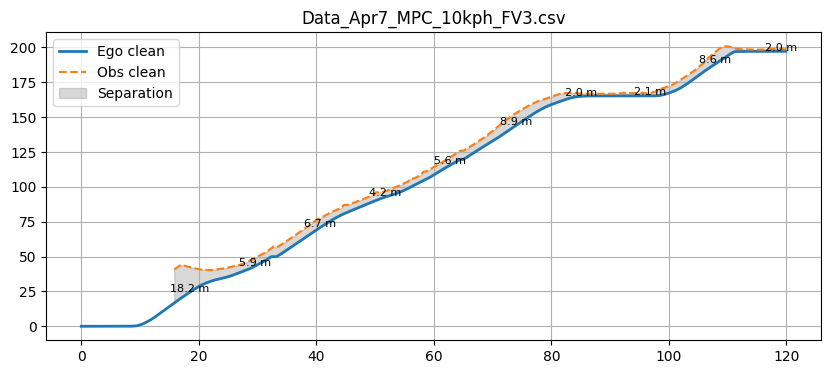

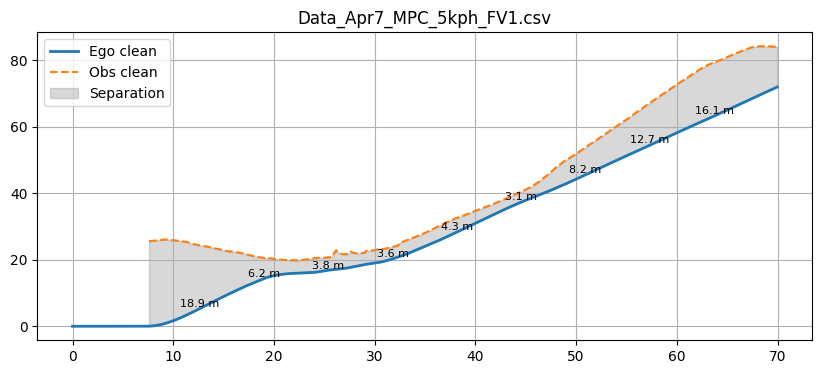

In [48]:
for file, df in data.items():
    plt.figure(figsize=(10,4))
    # plt.plot(df["Time"], df["Ego_Position(m)"], alpha=0.3, label="Ego raw")
    plt.plot(df["Time"], df["Ego_Position_clean"], label="Ego clean", linewidth=2)
    plt.plot(df["Time"], df["Obs_Position_clean"], label="Obs clean", linestyle="--")
    #show the gap between ego and obs as separation and show the value of separation as well
    plt.fill_between(df["Time"], df["Ego_Position_clean"], df["Obs_Position_clean"], color="gray", alpha=0.3, label="Separation")
    # Show the value of separation as text on the plot
    for i in range(0, len(df), max(1, len(df)//10)):  # Show text for up to 10 points
        if pd.notna(df.loc[i, "Separation_clean"]):
            plt.text(df.loc[i, "Time"], df.loc[i, "Ego_Position_clean"] + 0.5, f"{df.loc[i, 'Separation_clean']:.1f} m", fontsize=8, ha='center')       


    plt.legend(); plt.grid(); plt.title(file); plt.show()